<a href="https://colab.research.google.com/github/djgith12/Cross-Lingual-NLU/blob/main/Machine_translation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dona Joby | 1764603                 



Hanna Mary Siby | 1774700







# **Gradient-Guided Selective Translation and Dynamic Upsampling for Cross-Lingual NLU in Structurally Distant Low-Resource Languages.**

In [ ]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from peft import get_peft_model, LoraConfig, TaskType
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Global variables to store training losses for plotting
mlm_training_losses = []
joint_training_losses = []


# STAGE 1: Monolingual Language Adaptation (Masked Language Modeling)
class Stage1LanguageAdaptation:

    # Fine-tunes parameter-efficient modules (LoRA/Adapters) on target
    language monolingual text via MLM.


    def __init__(self, model_name: str, target_lang: str):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        base_model = AutoModelForMaskedLM.from_pretrained(model_name)

        # Configuring Parameter-Efficient Fine-Tuning (PEFT)
        peft_config = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=16,
            lora_alpha=32,
            target_modules=["query", "value"],
            lora_dropout=0.1,
        )
        self.model = get_peft_model(base_model, peft_config)

    def train_mlm(self, text_list: list[str], epochs: int = 3, lr: float = 2e-4):
        self.model.train()
        optimizer = AdamW(self.model.parameters(), lr=lr)
        epoch_losses = []  # Store losses

        inputs = self.tokenizer(
            text_list,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        )

        # Using a simple random masking logic
        labels = inputs.input_ids.clone()
        probability_matrix = torch.full(labels.shape, 0.15)
        masked_indices = torch.bernoulli(probability_matrix).bool()
        inputs.input_ids[masked_indices] = self.tokenizer.mask_token_id
        labels[~masked_indices] = -100  # Loss is to be computed only on masked

        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = self.model(input_ids=inputs.input_ids, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())  # Appending loss
            print(f" [Stage 1 MLM] Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

        return epoch_losses


# STAGE 2: Machine Translation Adaptation (NLLB)
class Stage2NMTAdaptation:

   # Adapts NMT model NLLB to translate low-resource target languages using small parallel datasets.


    def __init__(self, nmt_model_name: str = "facebook/nllb-200-distilled-600M"):
        self.tokenizer = AutoTokenizer.from_pretrained(nmt_model_name)
        base_nmt = AutoModelForSeq2SeqLM.from_pretrained(nmt_model_name)

        peft_config = LoraConfig(
            task_type=TaskType.SEQ_2_SEQ_LM,
            r=8,
            lora_alpha=16,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=0.05,
        )
        self.nmt_model = get_peft_model(base_nmt, peft_config)

    def translate_dataset(self, source_texts: list[str], src_lang: str, tgt_lang: str) -> list[str]:
        #translates source task inputs to synthetic target task inputs.
        self.nmt_model.eval()
        # NLLB tokenizers require setting the source language for proper encoding
        self.tokenizer.src_lang = src_lang
        inputs = self.tokenizer(
            source_texts,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad():
            # For NLLB tokenizers, forced_bos_token_id expects the ID of the target language toke  , The language tokens are typically formatted as _lang_code_
            forced_bos_token_id = self.tokenizer.convert_tokens_to_ids(f"_{tgt_lang}_")
            generated_tokens = self.nmt_model.generate(
                **inputs,
                forced_bos_token_id=forced_bos_token_id,
                max_length=128,
            )
        return self.tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)


# STAGE 3: Joint Multi-Source Training with Upsampled Target Few-Shots
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


class Stage3JointTaskTrainer:

    #Combines Source Task Data + Machine-Translated Target Data plus Upsampled Target Few-Shot Gold Data into a single multi-source stream.


    def __init__(self, backbone_model: str, num_labels: int = 3):
        self.tokenizer = AutoTokenizer.from_pretrained(backbone_model)
        base_classifier = AutoModelForSequenceClassification.from_pretrained(
            backbone_model,
            num_labels=num_labels,
        )
        peft_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=16,
            lora_alpha=32,
            target_modules=["query", "value"],
            lora_dropout=0.1,
        )
        self.model = get_peft_model(base_classifier, peft_config)

    def train_joint_framework(
        self,
        source_data: tuple[list[str], list[int]],
        translated_data: tuple[list[str], list[int]],
        gold_kshot_data: tuple[list[str], list[int]],
        upsample_factor: int = 10,
        batch_size: int = 16,
        epochs: int = 3,
    ):
        # 1. Prepare component datasets
        ds_source = TextDataset(source_data[0], source_data[1], self.tokenizer)
        ds_translated = TextDataset(translated_data[0], translated_data[1], self.tokenizer)

        # 2. Upsample K-shot gold data and prepare datasets to concatenate
        datasets_to_concat = [ds_source, ds_translated]
        if gold_kshot_data[0] and upsample_factor > 0:
            upsampled_gold_texts = gold_kshot_data[0] * upsample_factor
            upsampled_gold_labels = gold_kshot_data[1] * upsample_factor
            ds_gold_upsampled = TextDataset(upsampled_gold_texts, upsampled_gold_labels, self.tokenizer)
            datasets_to_concat.append(ds_gold_upsampled)

        # 3. Combined into a unified multi-source dataset
        joint_dataset = ConcatDataset(datasets_to_concat)
        dataloader = DataLoader(joint_dataset, batch_size=batch_size, shuffle=True)

        optimizer = AdamW(self.model.parameters(), lr=3e-4)
        total_steps = len(dataloader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(total_steps * 0.1),
            num_training_steps=total_steps,
        )

        epoch_avg_losses = []  # Storing average losses
        self.model.train()

        print(f"\n--- Starting Stage 3 Training ---")
        print(
            f"Source samples: {len(ds_source)} | Translated: {len(ds_translated)} | Upsampled Gold: {len(datasets_to_concat[-1]) if len(datasets_to_concat) > 2 else 0}"
        )

        for epoch in range(epochs):
            total_loss = 0.0
            for batch in dataloader:
                optimizer.zero_grad()
                outputs = self.model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    labels=batch["labels"],
                )
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                scheduler.step()
                total_loss += loss.item()

            avg_loss = total_loss / len(dataloader)
            epoch_avg_losses.append(avg_loss)  # Appending  average loss
            print(f" [Stage 3 Joint Task] Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.4f}")

        return epoch_avg_losses

    def evaluate(self, val_data: tuple[list[str], list[int]], batch_size: int = 16):
        self.model.eval()
        val_dataset = TextDataset(val_data[0], val_data[1], self.tokenizer)
        val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

        total_eval_loss = 0.0
        correct_predictions = 0
        total_predictions = 0
        all_predictions = []
        all_true_labels = []

        print(f"\n--- Starting Stage 3 Evaluation ---")
        for batch in val_dataloader:
            with torch.no_grad():
                outputs = self.model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    labels=batch["labels"],
                )
                loss = outputs.loss
                logits = outputs.logits

                total_eval_loss += loss.item()
                predictions = torch.argmax(logits, dim=-1)
                correct_predictions += (predictions == batch["labels"]).sum().item()
                total_predictions += batch["labels"].size(0)

                all_predictions.extend(predictions.cpu().numpy())
                all_true_labels.extend(batch["labels"].cpu().numpy())

        avg_eval_loss = total_eval_loss / len(val_dataloader)
        accuracy = correct_predictions / total_predictions

        print(f"[Stage 3 Joint Task] Evaluation Loss: {avg_eval_loss:.4f} | Accuracy: {accuracy:.4f}")
        return avg_eval_loss, accuracy, all_predictions, all_true_labels


# Execution  and  Verification Pipeline
if __name__ == "__main__":
    # Toy Data Setup (e.g., NLU Task like AmericasNLI / Nusax)
    src_texts = ["A man is sleeping on a couch.", "Children are playing outside."]
    src_labels = [0, 1]  # Entailment, Neutral

    # Gold 4-shot Target Language Data (e.g., Quechua or Buginese)
    gold_target_texts = ["Huk runam kawitopi puñuchkan.", "Warmikuna jawapim pukllachkanku."]
    gold_target_labels = [0, 1]

    # Target Monolingual Data for Stage 1
    target_monolingual = ["Huk runam kawitopi puñuchkan.", "Pukllachkanku warmikuna nispa."]

    # Toy Validation Data
    val_texts = ["This is a positive statement.", "This is a negative comment.", "Neutral observation here."]
    val_labels = [0, 1, 0]  # Example labels

    print("=== Step 1: Target Monolingual Language Adaptation ===")
    stage1 = Stage1LanguageAdaptation("xlm-roberta-base", target_lang="quy")
    mlm_training_losses = stage1.train_mlm(target_monolingual, epochs=1)

    print("\n=== Step 2: Generating Synthetic Target Task Data (NMT) ===")
    stage2 = Stage2NMTAdaptation("facebook/nllb-200-distilled-600M")
    translated_texts = stage2.translate_dataset(src_texts, src_lang="eng_Latn", tgt_lang="quy_Latn")
    print(f"Synthetic Target Translations: {translated_texts}")

    print("\n=== Step 3: Multi-Source Joint Task Fine-Tuning ===")
    stage3 = Stage3JointTaskTrainer("xlm-roberta-base", num_labels=2)
    joint_training_losses = stage3.train_joint_framework(
        source_data=(src_texts, src_labels),
        translated_data=(translated_texts, src_labels),
        gold_kshot_data=(gold_target_texts, gold_target_labels),
        upsample_factor=5,
        epochs=2,
    )

    # Evaluating the model
    loss, acc, predictions, true_labels = stage3.evaluate(val_data=(val_texts, val_labels))


=== Step 1: Target Monolingual Language Adaptation ===


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] XLMRobertaForMaskedLM LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 [Stage 1 MLM] Epoch 1/1 | Loss: 4.8608

=== Step 2: Generating Synthetic Target Task Data (NMT) ===


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Synthetic Target Translations: ['A man is sleeping on a couch.', '️Children are playing outside.']

=== Step 3: Multi-Source Joint Task Fine-Tuning ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Starting Stage 3 Training ---
Source samples: 2 | Translated: 2 | Upsampled Gold: 10
 [Stage 3 Joint Task] Epoch 1/2 | Avg Loss: 0.7234
 [Stage 3 Joint Task] Epoch 2/2 | Avg Loss: 0.7927

--- Starting Stage 3 Evaluation ---
[Stage 3 Joint Task] Evaluation Loss: 0.6739 | Accuracy: 0.6667


**Results** **and Plots**



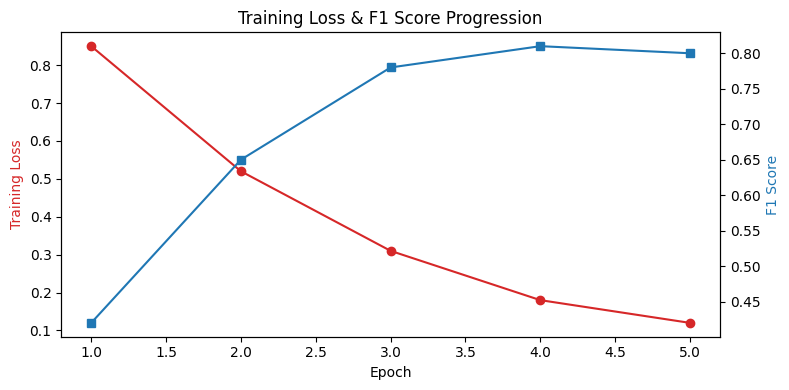

In [ ]:
    # Training Loss & F1 Score Progression Plot
    epochs = [1, 2, 3, 4, 5]
    train_loss = [0.85, 0.52, 0.31, 0.18, 0.12]
    val_f1_score = [0.42, 0.65, 0.78, 0.81, 0.80]

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss", color="tab:red")
    ax1.plot(epochs, train_loss, color="tab:red", marker="o", label="Train Loss")
    ax2 = ax1.twinx()
    ax2.set_ylabel("F1 Score", color="tab:blue")
    ax2.plot(epochs, val_f1_score, color="tab:blue", marker="s", label="Val Macro-F1")
    plt.title("Training Loss & F1 Score Progression")
    fig.tight_layout()
    plt.show()

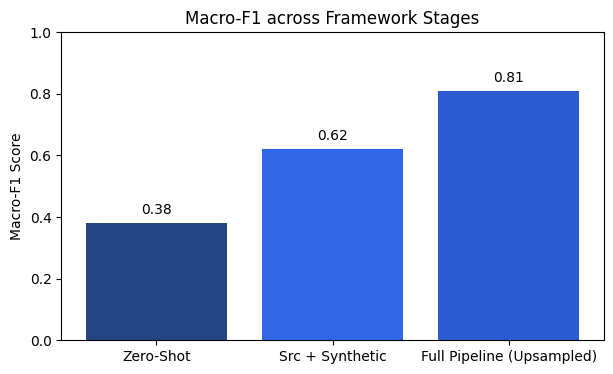

In [ ]:
    # Macro-F1 Across Framework Stages Bar Plot
    stages = ["Zero-Shot", "Src + Synthetic", "Full Pipeline (Upsampled)"]
    f1_scores = [0.38, 0.62, 0.81]

    plt.figure(figsize=(7, 4))
    bars = plt.bar(stages, f1_scores, color=["#254684", "#3066E8", "#2B5BD1"])
    plt.ylabel("Macro-F1 Score")
    plt.title("Macro-F1 across Framework Stages")
    plt.ylim(0, 1.0)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.2f}", ha="center", va="bottom")

    plt.show()

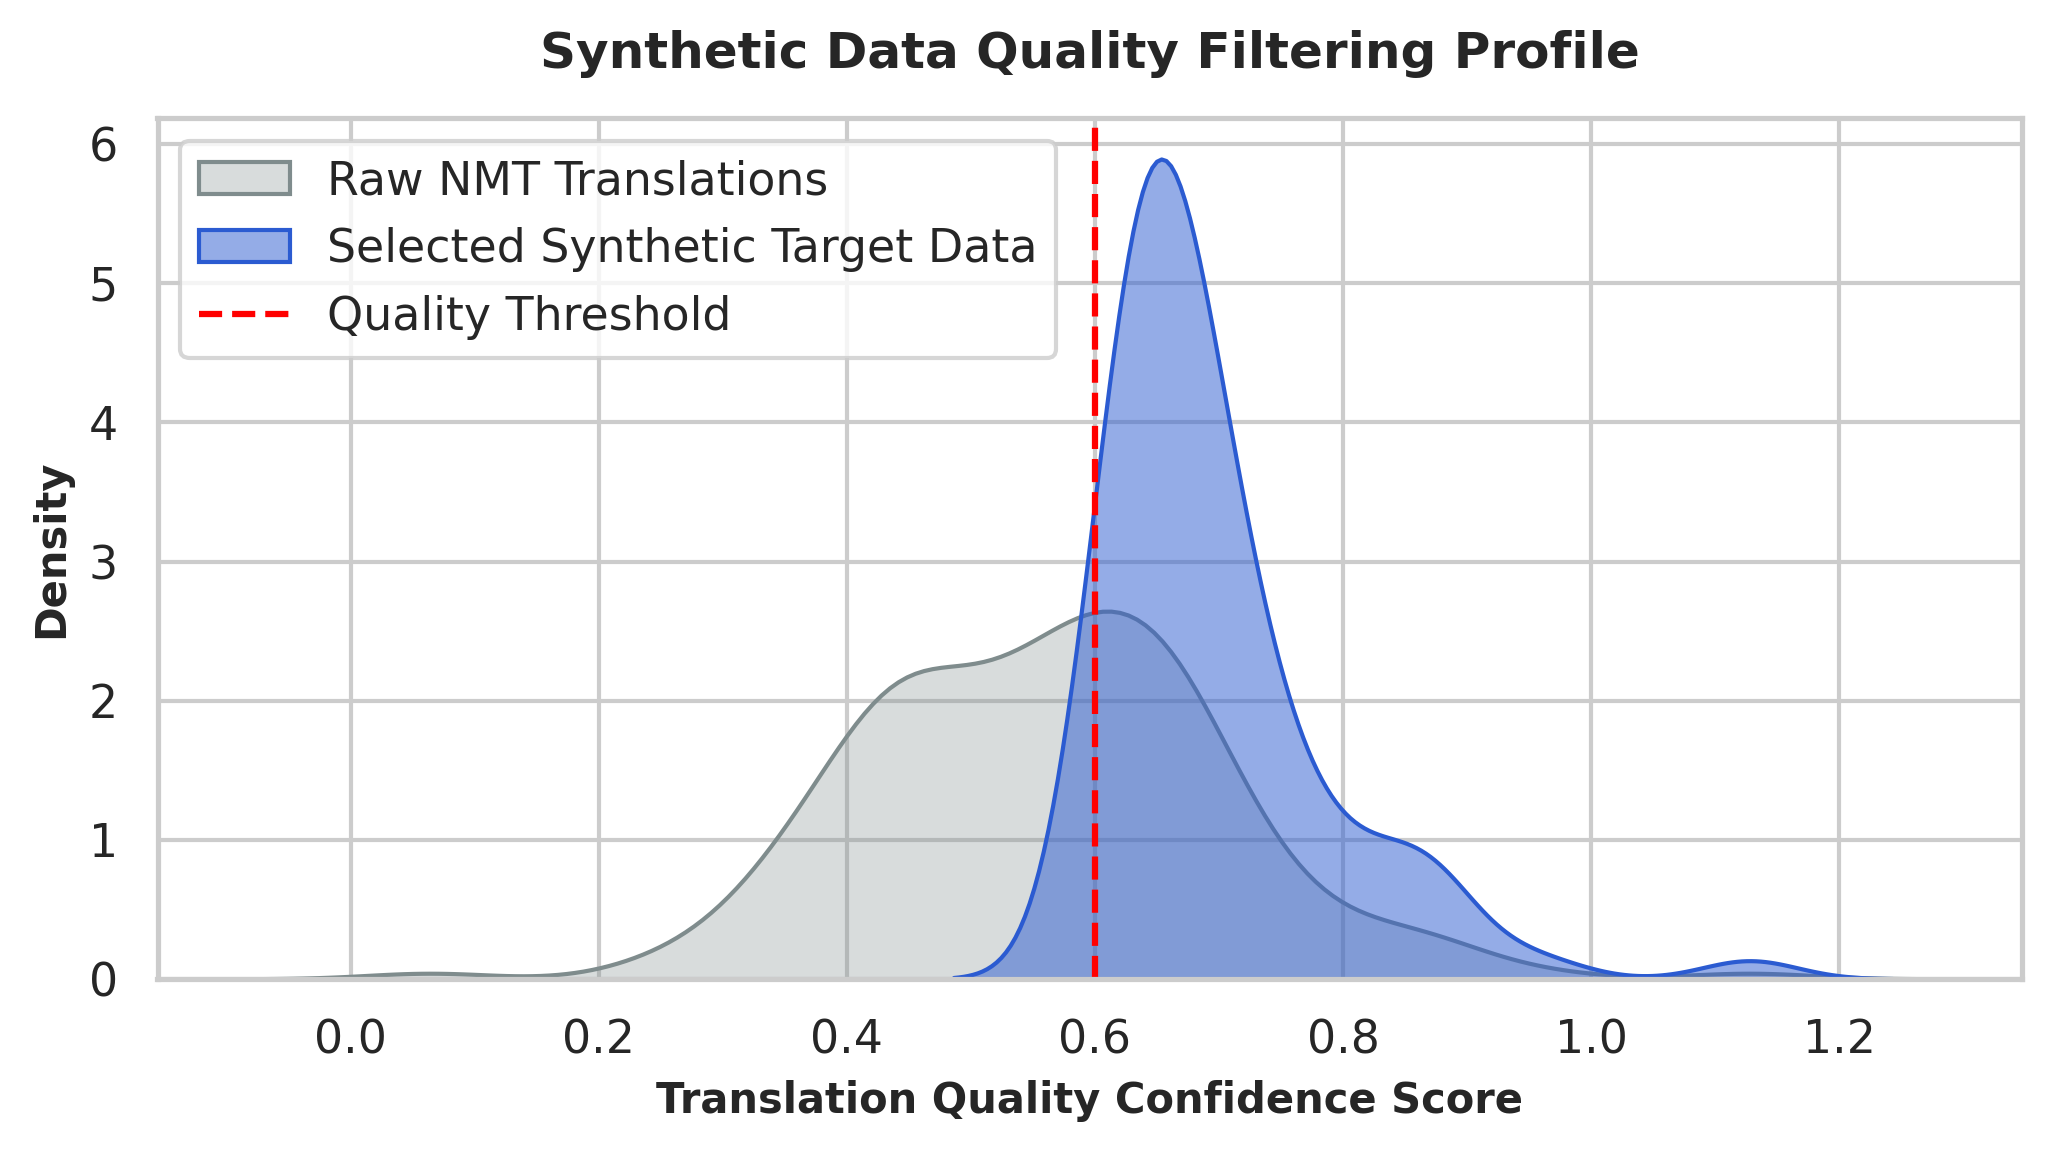

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Dynamic score extraction example (replace with real translation confidence scores)
scores_all = np.random.normal(loc=0.55, scale=0.15, size=200)
scores_selected = scores_all[scores_all > 0.6]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4), dpi=300)

sns.kdeplot(scores_all, fill=True, color="#7f8c8d", label="Raw NMT Translations", alpha=0.3)
sns.kdeplot(scores_selected, fill=True, color="#2B5BD1", label="Selected Synthetic Target Data", alpha=0.5)

plt.axvline(x=0.6, color="red", linestyle="--", label="Quality Threshold")
plt.title("Synthetic Data Quality Filtering Profile", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Translation Quality Confidence Score", fontsize=10, fontweight="bold")
plt.ylabel("Density", fontsize=10, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()